Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features...


100%|██████████| 600/600 [00:59<00:00, 10.01it/s]


Feature shapes: Train: (2800, 768) Val: (600, 768) Test: (600, 768)

===== Training with AttentionGuidedMixup =====
Epoch 1/50 - Train Loss: 2.0573  Val Loss: 1.9550
Epoch 2/50 - Train Loss: 2.0221  Val Loss: 1.8879
Epoch 3/50 - Train Loss: 1.9829  Val Loss: 1.8244
Epoch 4/50 - Train Loss: 1.9534  Val Loss: 1.7646
Epoch 5/50 - Train Loss: 1.9218  Val Loss: 1.7073
Epoch 6/50 - Train Loss: 1.8928  Val Loss: 1.6534
Epoch 7/50 - Train Loss: 1.8692  Val Loss: 1.6023
Epoch 8/50 - Train Loss: 1.8398  Val Loss: 1.5536
Epoch 9/50 - Train Loss: 1.8258  Val Loss: 1.5076
Epoch 10/50 - Train Loss: 1.8020  Val Loss: 1.4636
Epoch 11/50 - Train Loss: 1.7793  Val Loss: 1.4227
Epoch 12/50 - Train Loss: 1.7594  Val Loss: 1.3834
Epoch 13/50 - Train Loss: 1.7444  Val Loss: 1.3465
Epoch 14/50 - Train Loss: 1.7226  Val Loss: 1.3117
Epoch 15/50 - Train Loss: 1.7088  Val Loss: 1.2783
Epoch 16/50 - Train Loss: 1.6956  Val Loss: 1.2473
Epoch 17/50 - Train Loss: 1.6867  Val Loss: 1.2175
Epoch 18/50 - Train Loss: 

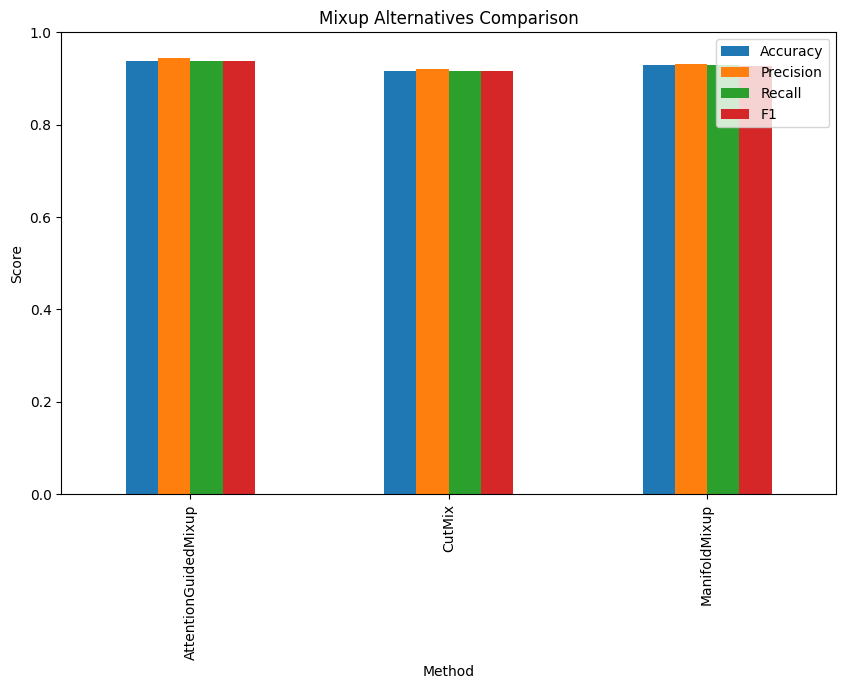

                      0         1         2         3         4
0  AttentionGuidedMixup  0.938333  0.944419  0.938333  0.937362
1                CutMix  0.916667  0.919608  0.916667  0.915261
2         ManifoldMixup  0.928333  0.930932  0.928333  0.927707


,0,1,2,3,4
0,AttentionGuidedMixup,0.938333,0.944419,0.938333,0.937362
1,CutMix,0.916667,0.919608,0.916667,0.915261
2,ManifoldMixup,0.928333,0.930932,0.928333,0.927707


In [5]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Minimal Transforms (Base)
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Mixup Alternatives (Feature-space)
# =========================

def attention_guided_mixup(X, y, mixup_count, alpha=0.5):
    """Feature-space Attention Guided Mixup (same as vanilla in this simplified setup)."""
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

def cutmix_features(X, y, mixup_count):
    """Simple 1D 'cut and paste' on feature vector (feature-space CutMix)."""
    mixX, mixy = [], []
    n, d = X.shape
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        cut_point = d // 2
        mixed = np.concatenate([X[i][:cut_point], X[j][cut_point:]])
        mixX.append(mixed)
        mixy.append(y[i])
    return np.array(mixX), np.array(mixy)

def manifold_mix_features(X, y, mixup_count, alpha=0.5):
    """Feature-space manifold mixup (mix parts of vector)."""
    mixX, mixy = [], []
    n, d = X.shape
    half = d // 2
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = np.concatenate([
            lam * X[i][:half] + (1 - lam) * X[j][:half],
            lam * X[i][half:] + (1 - lam) * X[j][half:]
        ])
        mixX.append(mixed)
        mixy.append(y[i])
    return np.array(mixX), np.array(mixy)

# ✅ Only keep distinct methods
AUGMENT_METHODS = {
    "AttentionGuidedMixup": attention_guided_mixup,
    "CutMix": cutmix_features,
    "ManifoldMixup": manifold_mix_features
}


# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

# =========================
# Training & Evaluation Loop (per method)
# =========================
results = []

for method_name, method_fn in AUGMENT_METHODS.items():
    print(f"\n===== Training with {method_name} =====")

    # Generate mixed features
    mixup_count = len(X_train_feats) * 2
    X_mix, y_mix = method_fn(X_train_feats, y_train, mixup_count)
    X_final, y_final = X_mix, y_mix

    # Dataloaders
    batch_size = 64
    train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                            torch.tensor(y_final, dtype=torch.long)),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                          torch.tensor(y_val, dtype=torch.long)),
                            batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                           torch.tensor(y_test, dtype=torch.long)),
                             batch_size=batch_size, shuffle=False)

    # Model
    in_features = X_final.shape[1]
    num_classes = len(CLASS_NAMES)
    model_head = ViTHead(in_features, num_classes, dropout_rate=0.4).to(device)

    # Criterion & Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-5, weight_decay=1e-4)

    # Training
    EPOCHS = 50
    PATIENCE = 5
    best_val_loss = float("inf")
    wait = 0
    best_model_path = f"{method_name}_best.pth"

    for epoch in range(EPOCHS):
        model_head.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model_head(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        # Validation
        model_head.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = criterion(model_head(xb), yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model_head.state_dict(), best_model_path)
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping.")
                break

    # Evaluation
    model_head.load_state_dict(torch.load(best_model_path))
    model_head.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = torch.argmax(model_head(xb), dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

    print(f"[{method_name}] Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
    results.append([method_name, acc, prec, rec, f1])

# =========================
# Results Table & Plot
# =========================
df_results = pd.DataFrame(results, columns=["Method", "Accuracy", "Precision", "Recall", "F1"])
print("\nFinal Comparison Table:")
print(df_results)

df_results.plot(x="Method", y=["Accuracy","Precision","Recall","F1"], kind="bar", figsize=(10,6))
plt.title("Mixup Alternatives Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

import pandas as pd

# Create table
df = pd.DataFrame(results)

# Display
print(df)

# If you want a nicer tabular view (Jupyter/Colab will render it as a table automatically):
df.style.set_table_styles(
    [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
     {'selector': 'td', 'props': [('font-size', '11pt'), ('text-align', 'center')]}]
).set_caption("Comparison of Mixup Methods (Tiny Swin V2 + LoRA Head)")